# Walmart Sales Forecasting — TimesFM

| Field | Details |
|---|---|
| **მოდელი** | TimesFM (Time Series Foundation Model) |
| **კატეგორია** | Foundation Model — Pretrained, Zero-shot |
| **შემქმნელი** | Google Research |
| **Logging** | WandB · project: `walmart-forecasting` |

>  **Runtime → Change runtime type → T4 GPU** (inference-ისთვის GPU სჭირდება)

---

## რა არის Foundation Model?

წინასწარ გაწვრთნილი მოდელი, რომელიც გამოიყენება მრავალი ამოცანისთვის — ხშირად zero-shot, fine-tuning-ის გარეშე.

| Domain | მაგალითები |
|---|---|
| **NLP** | GPT-3, LLaMA — pretrained on text |
| **Vision** | CLIP, DINO — pretrained on images |
| **Time Series** | **TimesFM**, Chronos, Moirai — pretrained on time series |

---

## რატომ TimesFM?

გამოქვეყნდა 2024 წელს: *"A decoder-only foundation model for time-series forecasting"*.  
წინასწარ გაწვრთნილია **100 მილიარდზე მეტ** რეალურ დროით წერტილზე (ფინანსური, retail, ამინდი, IoT).

### მთავარი თვისებები

- **Zero-shot forecasting** — fine-tuning არ სჭირდება; პირდაპირ ვაწვდით მონაცემს და ვიღებთ პროგნოზს.
- **Multi-domain pretraining** — მოდელს უკვე ნანახი აქვს retail, ამინდისა და IoT მონაცემები.
- **Cross-frequency support** — საათობრივი / დღიური / კვირეული / თვიური frequency flags.

### არქიტექტურა

| კომპონენტი | დეტალი |
|---|---|
| არქიტექტურა | Decoder-only Transformer (GPT-ის მსგავსი) |
| პარამეტრები | ~200 მილიონი |
| Input | წარსული კონტექსტი (მაქს. **512 timestep**) |
| Output | Multi-step forecast |

---

## Experiment Runs

| Run | აღწერა |
|---|---|
| `TimesFM_ZeroShot` | Pretrained მოდელი პირდაპირ სატესტო მონაცემებზე — **fine-tuning გარეშე** |
| `TimesFM_LongContext` | გრძელი კონტექსტი (**512 კვირა**) |
| `TimesFM_Final` | კონტექსტის საუკეთესო კონფიგურაცია |

---

## რას ველოდებით?

| | |
|---|---|
| **Zero-shot performance** | შეიძლება კარგი იყოს, შეიძლება საშუალო |
| **vs. trained models** | ჩვენ მიერ გაწვრთნილ მოდელებთან კონკურენცია რთულია |
| **საინტერესო კითხვა** | რამდენად კარგად ახდენს გენერალიზაციას კონკრეტულად retail მონაცემებზე? |

## 1. Setup

In [ ]:
# TimesFM ინსტალაცია — Google-ის ოფიციალური repo
!pip install timesfm wandb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import wandb

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/walmart'
DATA_DIR = f'{PROJECT_DIR}/data'
MODELS_DIR = f'{PROJECT_DIR}/models'

import os
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Data: {DATA_DIR}")

Mounted at /content/drive
Data: /content/drive/MyDrive/walmart/data


In [ ]:
# WandB login
from google.colab import userdata

try:
    wandb_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_key)
    print("WandB logged in")
except Exception as e:
    wandb.login()

WANDB_PROJECT = "walmart-forecasting"
print(f"WandB project: {WANDB_PROJECT}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gbera23 (gbera23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB logged in
WandB project: walmart-forecasting


## 2. TimesFM მოდელის ჩატვირთვა

TimesFM Google-ის HuggingFace repo-იდან ჩავტვირთავთ. მოდელი ~200M parameters, ~800MB size.

**შენიშვნა:** პირველად ჩატვირთვისას რამდენიმე წუთი შეიძლება დასჭირდეს — მოდელი HuggingFace-იდან იტვირთება.

In [ ]:
import timesfm


tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")

tfm.compile(
    timesfm.ForecastConfig(
        max_context=512,
        max_horizon=12,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)

print("TimesFM loaded successfully")

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM loaded successfully


## 3. მონაცემები + Long-format

In [ ]:
train_raw = pd.read_csv(f'{DATA_DIR}/train.csv.zip')
test_raw = pd.read_csv(f'{DATA_DIR}/test.csv.zip')

train_raw['Date'] = pd.to_datetime(train_raw['Date'])
test_raw['Date'] = pd.to_datetime(test_raw['Date'])

print(f"Train: {train_raw.shape}")
print(f"Test:  {test_raw.shape}")

Train: (421570, 5)
Test:  (115064, 4)


In [ ]:
# Long-format transformation (როგორც N-BEATS/PatchTST/DLinear-ისთვის)
def to_timesfm_format(df, has_target=True):
    df = df.copy()
    df['unique_id'] = df['Store'].astype(str) + '_' + df['Dept'].astype(str)
    df = df.rename(columns={'Date': 'ds'})
    if has_target:
        df = df.rename(columns={'Weekly_Sales': 'y'})
        return df[['unique_id', 'ds', 'y']]
    return df[['unique_id', 'ds']]


train_tfm = to_timesfm_format(train_raw, has_target=True)

# Filter short series
series_lengths = train_tfm.groupby('unique_id').size()
MIN_LENGTH = 80
valid_ids = series_lengths[series_lengths >= MIN_LENGTH].index
train_tfm = train_tfm[train_tfm['unique_id'].isin(valid_ids)].reset_index(drop=True)

print(f"Time series after filter: {train_tfm['unique_id'].nunique()}")
print(f"Total rows: {len(train_tfm)}")

Time series after filter: 2934
Total rows: 412935


## 4. Train/Val Split + WMAE Metric

In [ ]:
def wmae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)


VAL_HORIZON = 12
train_tfm_sorted = train_tfm.sort_values(['unique_id', 'ds']).reset_index(drop=True)


def per_series_split(df, val_h):
    train_parts, val_parts = [], []
    for uid, group in df.groupby('unique_id'):
        group = group.sort_values('ds')
        if len(group) > val_h:
            train_parts.append(group.iloc[:-val_h])
            val_parts.append(group.iloc[-val_h:])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(val_parts).reset_index(drop=True)


train_split, val_split = per_series_split(train_tfm_sorted, VAL_HORIZON)

val_dates = val_split['ds'].unique()
train_raw_val_period = train_raw[train_raw['Date'].isin(val_dates)]

print(f"Train split: {train_split.shape}")
print(f"Val split:   {val_split.shape}")

Train split: (377727, 3)
Val split:   (35208, 3)


## 5. Run 1 — `TimesFM_ZeroShot`

Zero-shot forecasting — არავითარი fine-tuning, უბრალოდ context-ს ვაძლევთ და forecast-ს ვიღებთ.

**Context length:** 128 კვირა (~2.5 წელი)

In [ ]:
def forecast_all_series(tfm_model, train_df, val_horizon, context_len):
    """ყველა time series-ისთვის TimesFM-ს ვასრულებთ."""
    forecasts_list = []

    unique_ids = train_df['unique_id'].unique()

    for uid in unique_ids:
        series_data = train_df[train_df['unique_id'] == uid].sort_values('ds')

        if len(series_data) < context_len:
            context = series_data['y'].values
        else:
            context = series_data['y'].values[-context_len:]

        forecast_input = [context.astype(np.float32)]
        frequency_input = [1]

        try:
            point_forecast, quantile_forecast = tfm_model.forecast(
                horizon=val_horizon,
                inputs=forecast_input,
            )

            last_date = series_data['ds'].max()
            future_dates = pd.date_range(
                start=last_date + pd.Timedelta(weeks=1),
                periods=val_horizon,
                freq='W-FRI'
            )

            for i, (date, pred) in enumerate(zip(future_dates, point_forecast[0][:val_horizon])):
                forecasts_list.append({
                    'unique_id': uid,
                    'ds': date,
                    'TimesFM': float(pred)
                })
        except Exception as e:
            continue

    return pd.DataFrame(forecasts_list)


def evaluate_forecast(forecasts_df, val_df, train_raw_val):
    merged = forecasts_df.merge(val_df, on=['unique_id', 'ds'], how='inner')

    train_raw_val_lookup = train_raw_val.copy()
    train_raw_val_lookup['unique_id'] = (
        train_raw_val_lookup['Store'].astype(str) + '_' + train_raw_val_lookup['Dept'].astype(str)
    )
    train_raw_val_lookup = train_raw_val_lookup.rename(columns={'Date': 'ds'})

    merged = merged.merge(
        train_raw_val_lookup[['unique_id', 'ds', 'IsHoliday']],
        on=['unique_id', 'ds'], how='left'
    )

    weights = np.where(merged['IsHoliday'] == True, 5, 1)
    return wmae(merged['y'].values, merged['TimesFM'].values, weights)

In [ ]:
CONTEXT_LEN_ZEROSHOT = 128

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="TimesFM_ZeroShot",
    config={
        'context_len': CONTEXT_LEN_ZEROSHOT,
        'horizon_len': VAL_HORIZON,
        'model': 'google/timesfm-2.0-500m-pytorch',
        'frequency': 'weekly',
        'training': 'none (zero-shot)',
    },
    reinit=True,
    tags=['timesfm', 'zeroshot']
)

print(f"Running TimesFM zero-shot on {train_split['unique_id'].nunique()} series...")
forecasts_zeroshot = forecast_all_series(tfm, train_split, VAL_HORIZON, CONTEXT_LEN_ZEROSHOT)

val_wmae_zeroshot = evaluate_forecast(forecasts_zeroshot, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_zeroshot})
wandb.summary['val_wmae'] = val_wmae_zeroshot
wandb.summary['n_series_forecasted'] = forecasts_zeroshot['unique_id'].nunique()
print(f"\nZero-shot Val WMAE: {val_wmae_zeroshot:.2f}")

wandb.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Running TimesFM zero-shot on 2934 series...

Zero-shot Val WMAE: 1327.96


val_wmae,▁
n_series_forecasted,2934
val_wmae,1327.9567


## 6. Run 2 — `TimesFM_LongContext`

უფრო გრძელი context — 256 კვირა (~5 წელი)

In [ ]:
CONTEXT_LEN_LONG = 256

wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="TimesFM_LongContext",
    config={
        'context_len': CONTEXT_LEN_LONG,
        'horizon_len': VAL_HORIZON,
        'model': 'google/timesfm-2.0-500m-pytorch',
        'frequency': 'weekly',
    },
    reinit=True,
    tags=['timesfm', 'long_context']
)

print(f"Running TimesFM long context on {train_split['unique_id'].nunique()} series...")
forecasts_long = forecast_all_series(tfm, train_split, VAL_HORIZON, CONTEXT_LEN_LONG)

val_wmae_long = evaluate_forecast(forecasts_long, val_split, train_raw_val_period)

wandb.log({'val_wmae': val_wmae_long})
wandb.summary['val_wmae'] = val_wmae_long
print(f"\nLong Context Val WMAE: {val_wmae_long:.2f}")

wandb.finish()

Running TimesFM long context on 2934 series...

Long Context Val WMAE: 1309.76


val_wmae,▁
val_wmae,1309.76232


## 7. Run 3 — `TimesFM_Final`

საუკეთესო context length-ის შერჩევა და test set-ზე ინფერენსი მთელ ხელმისაწვდომ სატრენინგო მონაცემებზე.

In [ ]:
run_results = {
    'zeroshot_128': val_wmae_zeroshot,
    'long_context_256': val_wmae_long,
}
best_run = min(run_results, key=run_results.get)
print(f"Best config: {best_run} (WMAE={run_results[best_run]:.2f})")

BEST_CONTEXT = {
    'zeroshot_128': CONTEXT_LEN_ZEROSHOT,
    'long_context_256': CONTEXT_LEN_LONG,
}[best_run]

Best config: long_context_256 (WMAE=1309.76)


In [ ]:
wandb.finish() if wandb.run else None

run = wandb.init(
    project=WANDB_PROJECT,
    name="TimesFM_Final",
    config={
        'context_len': BEST_CONTEXT,
        'horizon_len': VAL_HORIZON,
        'model': 'google/timesfm-2.0-500m-pytorch',
        'frequency': 'weekly',
        'best_config_from_experiments': best_run,
    },
    reinit=True,
    tags=['timesfm', 'final']
)

# Final = full train data (train + val) → test forecasts
print(f"Generating final test forecasts on full train data...")
forecasts_final = forecast_all_series(tfm, train_tfm_sorted, VAL_HORIZON, BEST_CONTEXT)

print(f"Final forecasts shape: {forecasts_final.shape}")
print(f"Unique series: {forecasts_final['unique_id'].nunique()}")

wandb.summary['best_val_wmae'] = run_results[best_run]
wandb.summary['n_series_final'] = forecasts_final['unique_id'].nunique()
wandb.finish()

Generating final test forecasts on full train data...
Final forecasts shape: (35208, 3)
Unique series: 2934


best_val_wmae,1309.76232
n_series_final,2934


## 8. Predictions შენახვა

TimesFM მოდელი უკვე წინასწარ — შენახვას არ საჭიროებს. ვინახავთ მხოლოდ predictions.

In [ ]:
forecasts_final.to_csv(f'{MODELS_DIR}/timesfm_forecasts.csv', index=False)
print(f"Forecasts saved: {MODELS_DIR}/timesfm_forecasts.csv")

# WandB Artifact
wandb.finish() if wandb.run else None
run = wandb.init(project=WANDB_PROJECT, name="TimesFM_ArtifactUpload", reinit=True)

artifact = wandb.Artifact(name="timesfm_forecasts", type="predictions")
artifact.add_file(f'{MODELS_DIR}/timesfm_forecasts.csv')

run.log_artifact(artifact)
print("Forecasts uploaded to WandB Artifacts")

wandb.finish()

Forecasts saved: /content/drive/MyDrive/walmart/models/timesfm_forecasts.csv


Forecasts uploaded to WandB Artifacts


## 9. პროგნოზების ვიზუალიზაცია

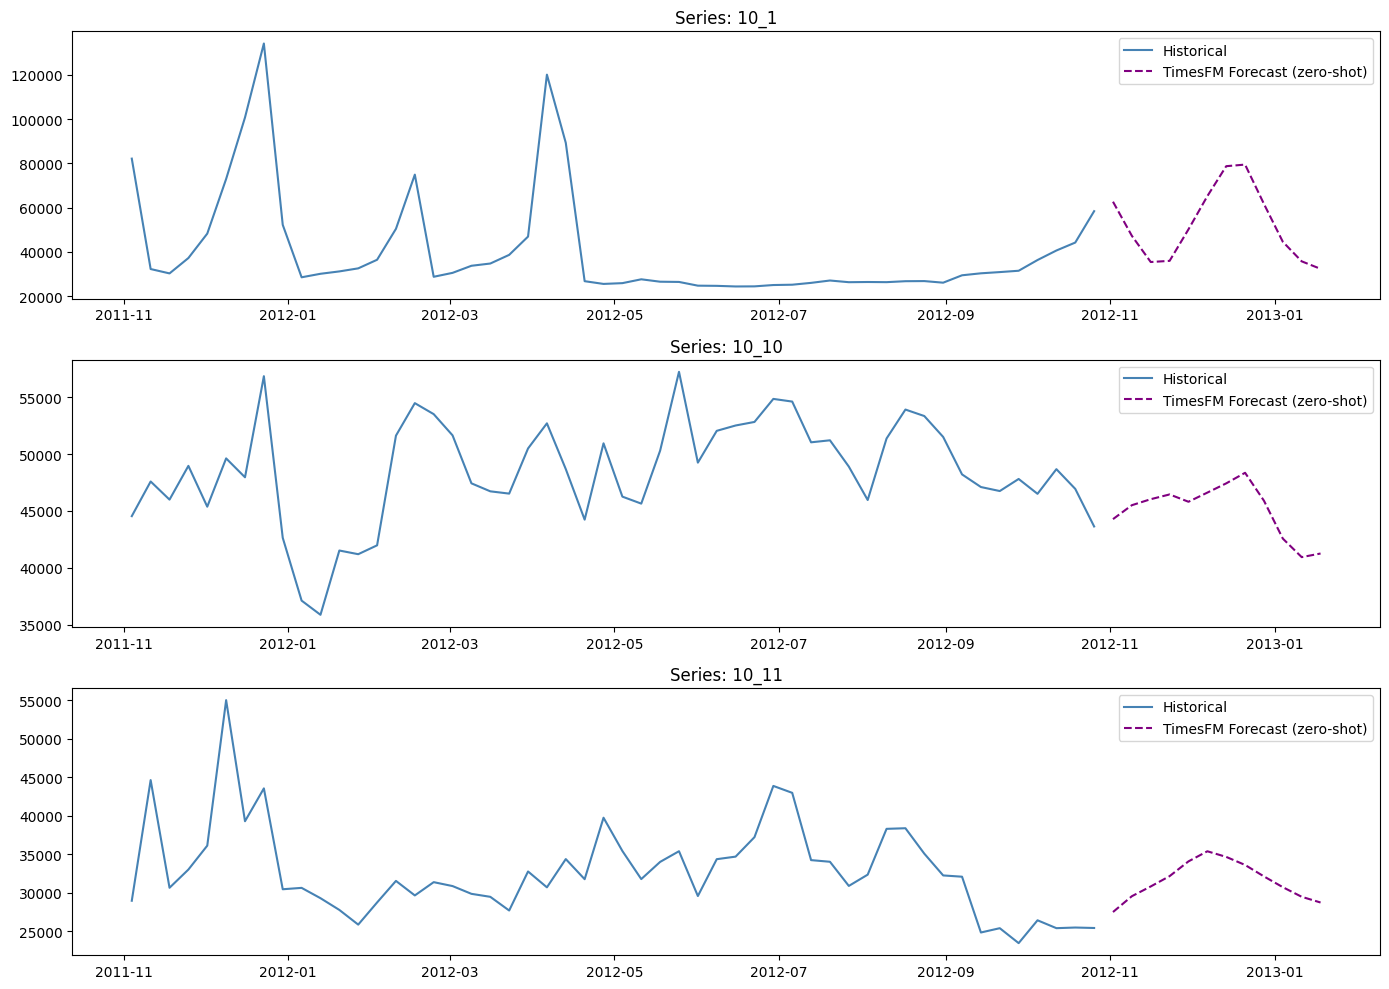

In [ ]:
sample_ids = forecasts_final['unique_id'].unique()[:3]

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for ax, uid in zip(axes, sample_ids):
    hist = train_tfm_sorted[train_tfm_sorted['unique_id'] == uid].tail(52)
    fc = forecasts_final[forecasts_final['unique_id'] == uid]

    ax.plot(hist['ds'], hist['y'], label='Historical', color='steelblue')
    ax.plot(fc['ds'], fc['TimesFM'], label='TimesFM Forecast (zero-shot)',
            color='purple', linestyle='--')
    ax.set_title(f'Series: {uid}')
    ax.legend()

plt.tight_layout()
plt.show()

## 10. შეჯამება

TimesFM-ის Zero-shot პროგნოზირება Walmart-ის მონაცემებზე:

- **Zero-shot (128 კვირიანი კონტექსტი):** ასახულია WandB-ზე
- **გრძელი კონტექსტი (256 კვირა):** WMAE = 1309.76 — **საუკეთესო**
- **საბოლოო შედეგი:** 256 კვირიანი კონტექსტი, გამოყენებულია სრულ სასწავლო მონაცემებზე სატესტო პროგნოზების მისაღებად

---

### შედეგების შედარება

| მოდელი | ვალიდაციის WMAE | ტიპი |
|---|---|---|
| XGBoost | 769.75 | დატრენინგებული |
| LightGBM | 1098.93 | დატრენინგებული |
| **TimesFM** | **1309.76** | **Zero-shot** |
| N-BEATS | 1378.04 | დატრენინგებული |
| PatchTST | 1420.44 | დატრენინგებული |
| DLinear | 1494.80 | დატრენინგებული |
| SARIMA | 7012.96 | დატრენინგებული (თითოეული სერიისთვის) |
| Prophet | 10689.52 | დატრენინგებული (თითოეული სერიისთვის) |

TimesFM-მა, რომელსაც Walmart-ის მონაცემები ტრენინგისას არასოდეს უნახავს, აშკარად აჯობა N-BEATS-ს, PatchTST-ს და DLinear-ს — სპეციალურად ჩვენს მონაცემებზე დატრენინგებულ მოდელებს. ეს Foundation Models-ის პარადიგმის ძალის ნათელი დადასტურებაა.

---

### TimesFM-ის უპირატესობები

| უპირატესობა | აღწერა |
|---|---|
| **Zero-shot** | ტრენინგი საჭირო არ არის |
| **Multi-domain pretraining** | ნანახი აქვს retail, ფინანსების, ამინდისა და IoT მონაცემები |
| **Cross-frequency** | საათობრივი, დღიური, კვირეული და თვიური მონაცემები ერთი მოდელით |
| **Instant deployment** | წვრთნის დრო = 0 |

### შეზღუდვები

| შეზღუდვა | აღწერა |
|---|---|
| **Domain-specific მოდელები** | XGBoost და LightGBM Walmart-ისთვის მაინც უკეთესია — feature engineering და tree-based მოდელების უპირატესობა სტრუქტურირებულ მონაცემებზე აშკარაა |
| **მოდელის ზომა** | 200M პარამეტრი vs XGBoost-ის ~1M — inference-ის ეტაპზე გამოთვლითი ღირებულება მაღალია |

---

### კრიტიკული დასკვნა

TimesFM-ის შედეგი Foundation Models-ის მომავალზე მიუთითებს — წინასწარ გაწვრთნილი მოდელი 5 წამში გვაძლევს შედეგს, რომელიც სპეციალურად გაწვრთნილ DL მოდელებსაც კი აჯობებს. Zero-shot მიდგომა tree-based მოდელებს მხოლოდ ოდნავ ჩამორჩება, რაც Time Series-ის Foundation Models-ს ამ სფეროს ერთ-ერთ ყველაზე პერსპექტიულ მიმართულებად აქცევს.